In [1]:
import os
import eos
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from wquantiles import quantile_1D

colors = eos.figure.ItemColorCycler()._colors

In [2]:
class VerticalLineHandler(HandlerBase):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent,
        width, height, fontsize, trans
    ):
        line = Line2D(
        [xdescent + width / 2] * 2,
        [ydescent - 0.2 * height, ydescent + 1.2 * height],
        color=orig_handle.get_color(),
        linestyle=orig_handle.get_linestyle(),
        linewidth=orig_handle.get_linewidth(),
        transform=trans,
        )
        return [line]

In [3]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.850509 #pi-omega threshold

In [4]:
analysis_directory = os.getcwd()

fits = [
    (
        'All w/o Belle, N = 6',
        'tau-data-together',
        'FF-fp-I1-order6-without-Belle',
        'C0',
    ),
    (
        'All w/o Belle, N = 8',
        'tau-data-together',
        'FF-fp-I1-order8-without-Belle',
        'C1',
    ),
    (
        'Belle, N = 8',
        'tau-data-seperate',
        'FF-fp-I1-order8-Belle',
        'C2',
    ),
]

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


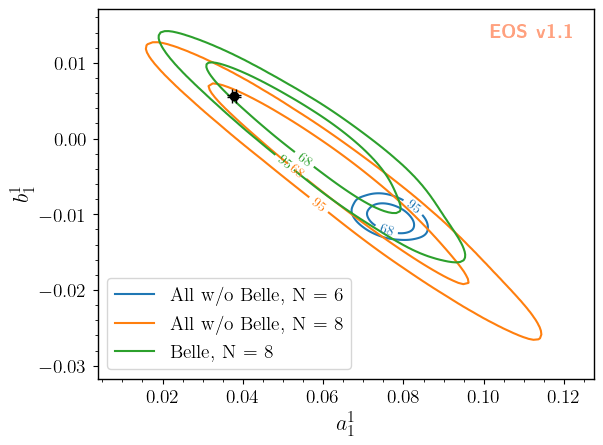

In [8]:
items = []
x_limits = []
y_limits = []

for label, folder, posterior, color in fits:
    samples_path = os.path.join(
        analysis_directory,
        folder,
        'data',
        posterior,
        'scattering-lengths',
        'samples',
    )

    fit = eos.data.ImportanceSamples(samples_path)

    # These saved samples have a11 in column 0 and b11 in column 1.
    a11 = fit.samples[:, 0]
    b11 = fit.samples[:, 1]
    weights = fit.weights

    def local_range(values):
        lower = float(quantile_1D(values, weights, 0.001))
        upper = float(quantile_1D(values, weights, 0.999))
        padding = 0.10 * (upper - lower)
        return [lower - padding, upper + padding]

    a11_range = local_range(a11)
    b11_range = local_range(b11)

    x_limits.append(a11_range)
    y_limits.append(b11_range)

    items.append({
        'type': 'kde2D',
        'label': label,
        'color': color,
        'levels': [68, 95],
        'bandwidth': 2.0,
        'contours': ['lines','labels'],
        'datafile': samples_path,
        'variables': ['derived::a11', 'derived::b11'],
        'xrange': a11_range,
        'yrange': b11_range,
    })

# Literature reference on the same a11–b11 plot.
items.append({
    'type': 'errorbars',
    'positions': [[0.0379, 0.00567]],
    'xerrors': [0.0005],
    'yerrors': [0.00013],
    'marker': 'o',
    'color': 'black',
    'alpha': 1.0,
    # 'label': 'CGL 2001'
    })

figure_args = {
    'plot': {
        'xaxis': {
            'label': r'$a^{1}_{1}$',
            'range': [
                min([bounds[0] for bounds in x_limits] + [0.0379 - 0.0005]),
                max([bounds[1] for bounds in x_limits] + [0.0379 + 0.0005]),
            ],
        },
        'yaxis': {
            'label': r'$b^{1}_{1}$',
            'range': [
                min([bounds[0] for bounds in y_limits] + [0.00567 - 0.00013]),
                max([bounds[1] for bounds in y_limits] + [0.00567 + 0.00013]),
            ],
        },
        'legend': {'position': 'lower left'},
        'items': items,
    },
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
figure.save('figures/a11vsb11.pdf')
plt.show()

In [7]:
coupling_labels = [
    ("derived::Re{g_rho_gamma}", r"$\mathrm{Re}\,g_{\rho\gamma}$"),
    ("derived::Im{g_rho_gamma}", r"$\mathrm{Im}\,g_{\rho\gamma}$"),
    ("derived::Re{g_rho_pi_pi}", r"$\mathrm{Re}\,g_{\rho\pi\pi}$"),
    ("derived::Im{g_rho_pi_pi}", r"$\mathrm{Im}\,g_{\rho\pi\pi}$"),
]

plot_parameters = eos.Parameters()

for name, latex in coupling_labels:
    if not plot_parameters.has(name):
        plot_parameters.declare_and_insert(
            name, latex, eos.Unit.Unity(),
            0.0, -100.0, 100.0,
        )

Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_gamma}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Im{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Im{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Im{g_rho_gamma}' and 'derived::Re{g_rho_pi_pi}'
Computing KDE for samples of variables 'derived::Re{g_rho_gamma}' and 'derived::Im{g_rho_pi_pi}'
Computing KDE for samples of v

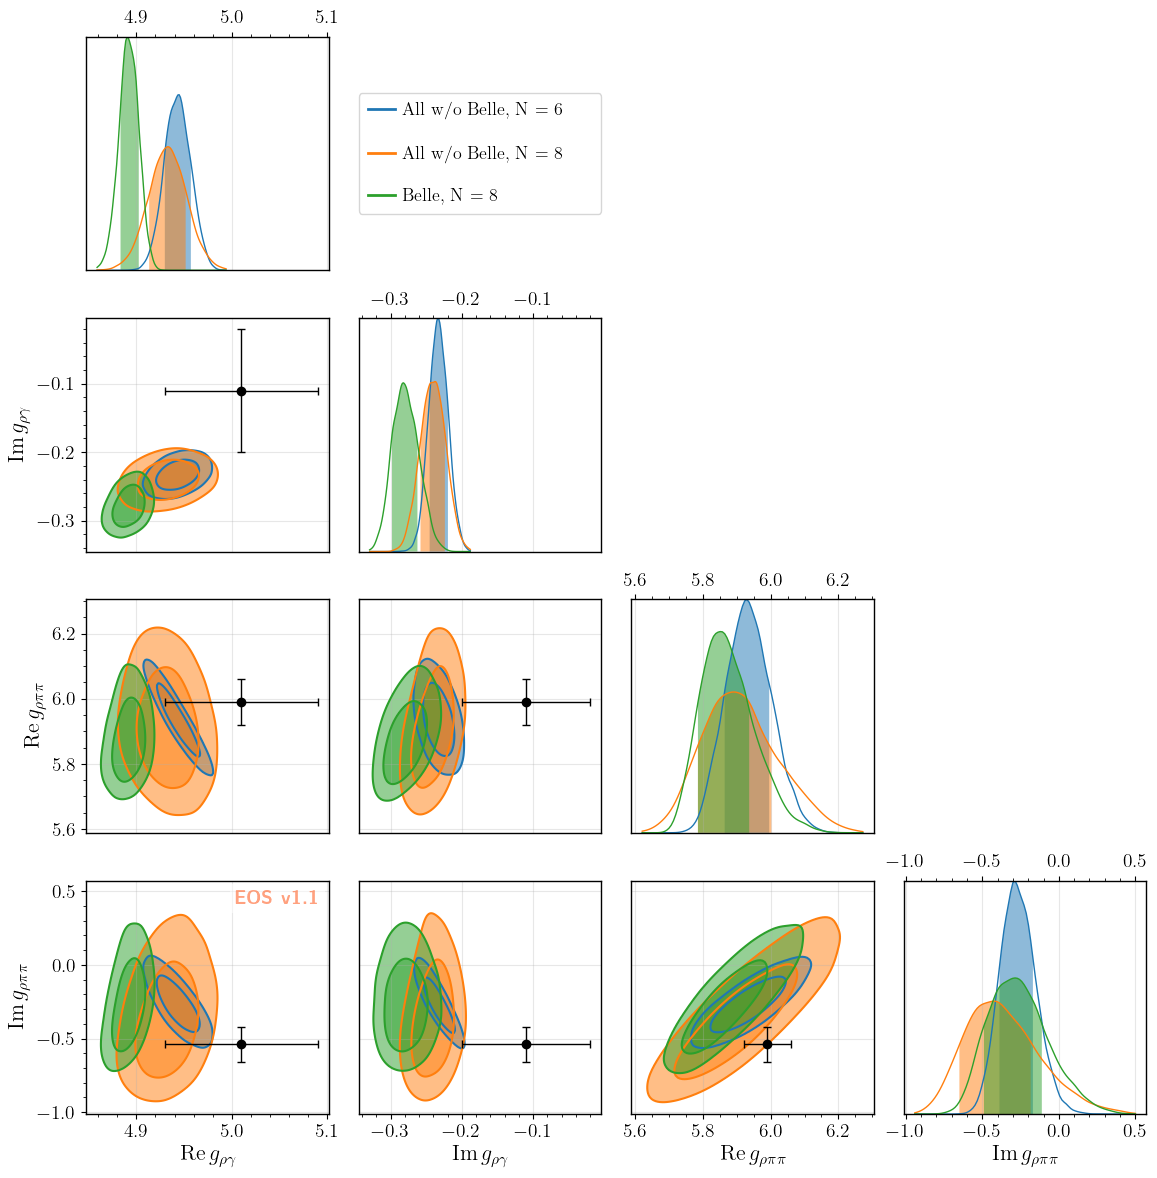

In [10]:
variables = [name for name, _ in coupling_labels]
contents = []

for label, folder, posterior, color in fits:
    samples_path = os.path.join(
        analysis_directory,
        folder,
        'data',
        posterior,
        'rho-couplings',
        'samples',
    )

    samples = eos.data.ImportanceSamples(samples_path)
    sample_variables = [
        entry['name'] for entry in samples.varied_parameters
    ]

    if sample_variables != variables:
        raise ValueError(
            f'{label}: expected {variables}, '
            f'found {sample_variables}'
        )

    contents.append({
        'path': samples_path,
        'label': label,
        'color': color,
        'kde': True,
    })

# Literature values in the same order as variables.
theory = [5.01, -0.11, 5.99, -0.54]
theory_errors = [0.08, 0.09, 0.07, 0.12]

figure = eos.figure.CornerFigure.from_dict(
    contents=contents,
    variables=variables,
    kde=True,
)

figure.prepare()
grid = figure._figure

# Increase smoothing in the 2D KDE panels.
for panel in grid.plots:
    for item in getattr(panel, 'items', []):
        if isinstance(
            item,
            eos.figure.item.TwoDimensionalKernelDensityEstimateItem,
        ):
            item.bandwidth = 2
            item.prepare()

    for attribute in ('xaxis', 'yaxis'):
        axis = getattr(panel, attribute, None)
        if axis is not None and axis.label:
            axis.label = '$' + axis.label.strip().strip('$') + '$'

figure.draw()

size = len(variables)
axes = grid._axes

# Extend the axis ranges to include the literature point and errors.
limits = []

for i in range(size):
    lower, upper = axes[i * size + i].get_xlim()
    lower = min(lower, theory[i] - theory_errors[i])
    upper = max(upper, theory[i] + theory_errors[i])
    padding = 0.05 * (upper - lower)
    limits.append((lower - padding, upper + padding))

theory_handle = None

for i in range(size):
    axes[i * size + i].set_xlim(limits[i])

    for j in range(i):
        ax = axes[i * size + j]

        handle = ax.errorbar(
        theory[j],
        theory[i],
        xerr=theory_errors[j],
        yerr=theory_errors[i],
        fmt='o',
        color='black',
        markersize=6,
        capsize=3,
        elinewidth=1.0,
        zorder=10)

        if theory_handle is None:
            theory_handle = handle

        ax.set_xlim(limits[j])
        ax.set_ylim(limits[i])

legend_handles = [
    Line2D([0], [0], color=color, linewidth=2)
    for _, _, _, color in fits
]
legend_labels = [label for label, _, _, _ in fits]

legend_handles.append(theory_handle)
#legend_labels.append('2312.15015')

# Place the legend in the empty top-row cell next to the first plot.
fig = axes[0].figure
legend_cell = axes[1]
cell = legend_cell.get_position()

fig.legend(
    legend_handles,
    legend_labels,
    loc='center',
    bbox_to_anchor=(cell.x0, cell.y0, cell.width, cell.height),
    bbox_transform=fig.transFigure,
    mode='expand',
    borderaxespad=0,
    frameon=True,
    fontsize=13,
    handlelength=1.5,
    handletextpad=0.4,
    labelspacing=1.4,
    borderpad=0.5,
)

figure.save('figures/gcornerplot.pdf')
plt.show()

In [95]:
def plot_ff2_fits(fits, analysis_directory):
    constraint_items = [
         {
                'type': 'constraint',
                'label': 'ALEPH 2013',
                'color': colors[4],
                'variable': 'q2',
                'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
                'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        {
            'type': 'constraint',
            'label': 'Belle 2008',
            'color': colors[0],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
            'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
        },
        {
            'type': 'constraint',
            'label': 'CLEO 2000',
            'color': colors[1],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
            'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        {
            'type': 'constraint',
            'label': 'OPAL 1999',
            'color': colors[5],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
            'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        },
        {
            'type': 'constraint',
            'label': 'NA7 1986',
            'color': colors[8],
            'variable': 'q2',
            'observable': '0->pipi::Abs{f_+}^2(q2)',
            'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
        },
    ]

    figures = {}

    output_names = {
        'FF-fp-I1-order6-without-Belle': 'ffwo6',
        'FF-fp-I1-order8-without-Belle': 'ffwo8',
        'FF-fp-I1-order8-Belle': 'ffbelle8',
    }

    for label, folder, posterior, _ in fits:
        prediction_file = os.path.join(
            analysis_directory,
            folder,
            'data',
            posterior,
            'pred-FF-fp2-I1-all',
        )
        if not os.path.isdir(prediction_file):
            raise FileNotFoundError(prediction_file)

        fit_item = {
            'type': 'uncertainty',
            'label': label,
            'color': 'C2',
            'alpha': 0.25,
            'variable': 'q2',
            'range': [-1.2, 2.0],
            'interpolation': 'cubic',
            'resolution': 300,
            'datafile': prediction_file,
        }

        main_items = constraint_items + [
            fit_item,
            {
                'type': 'band',
                'color': 'gray',
                'alpha': 0.25,
                'x': [sIn, 2.0],
                'y': [0.1, 100.0],
            },
        ]

        inset_fit_item = {
            **fit_item,
            'range': [0.4, 0.8],
            'resolution': 600,
        }
        inset_items = constraint_items + [inset_fit_item]

        figure = eos.figure.InsetFigure.from_dict(
            size=[10, 7],
            watermark={'position': 'lower right'},
            plot={
                'xaxis': {
                    'label': '$s$',
                    'unit': '$\\mathrm{GeV}^2$',
                    'range': [-1.2, 2.0],
                },
                'yaxis': {
                    'label': r'$|F_\pi|^2$',
                    'range': [0.1, 100.0],
                    'scale': 'log',
                },
                'legend': {'position': 'upper right'},
                'items': main_items,
            },
            inset={
                'position': [0.02, 0.65],  # left, bottom
                'size': [0.38, 0.32],      # width, height
                'plot': {
                'xaxis': {'range': [0.45, 0.7], 'ticks': {'visible': False},},
                'yaxis': {'range': [20.0, 50.0], 'ticks': {'visible': False},'scale': 'log'},
                'items': inset_items,},
            },
        )

        figure.draw()
        figure.save(f'figures/{output_names[posterior]}.pdf')
        figures[posterior] = figure
        plt.show()

    return figure

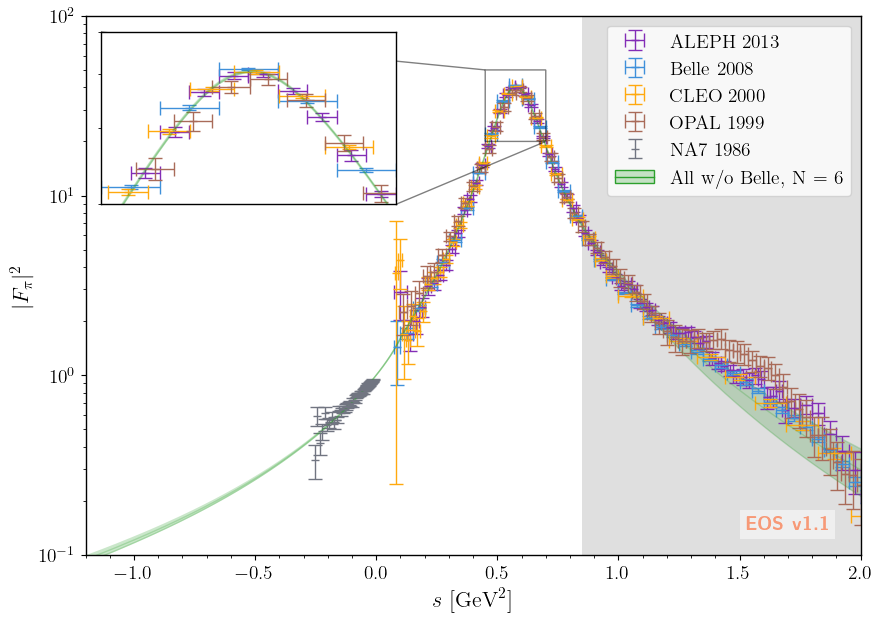

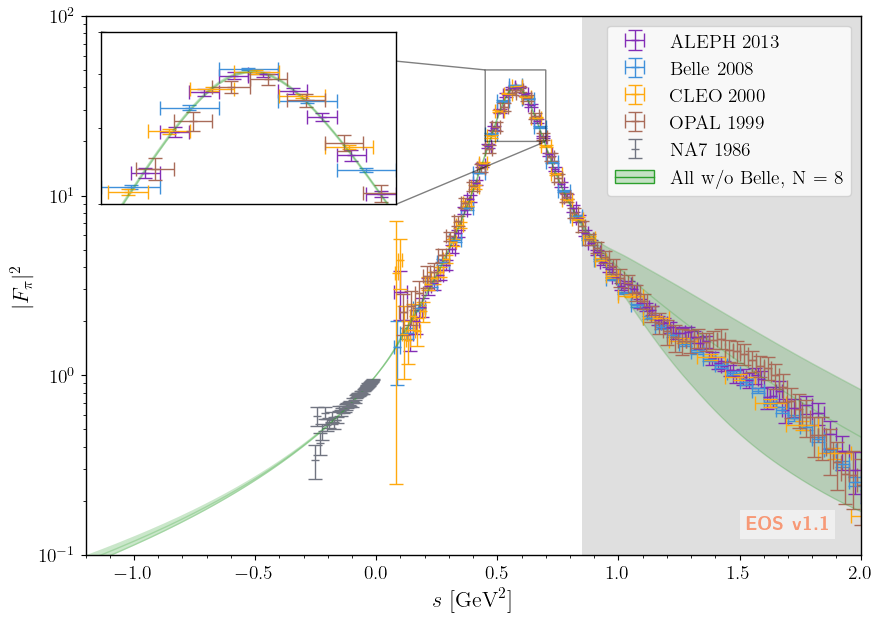

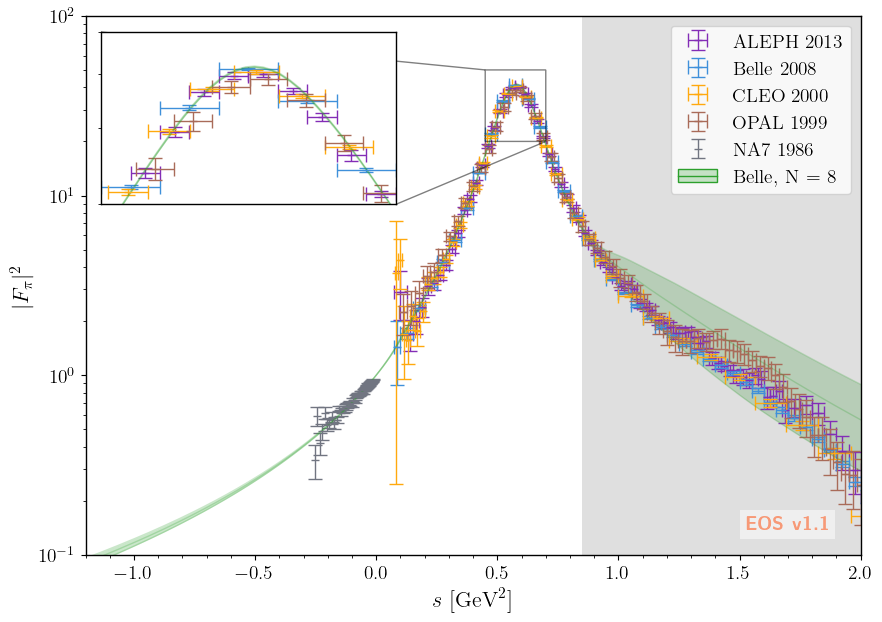

In [96]:
ff_figures = plot_ff2_fits(fits, analysis_directory)

In [130]:
def plot_t11_fits(fits, analysis_directory):
    figures = {}

    output_names = {
        'FF-fp-I1-order6-without-Belle': 't11wo6',
        'FF-fp-I1-order8-without-Belle': 't11wo8',
        'FF-fp-I1-order8-Belle': 't11belle8',
    }

    for label, folder, posterior, _ in fits:
        fit_directory = os.path.join(
            analysis_directory, folder, 'data', posterior
        )
        real_path = os.path.join(
            fit_directory, 'pred-real-partial-wave-I1'
        )
        imag_path = os.path.join(
            fit_directory, 'pred-imag-partial-wave-I1'
        )

        for path in (real_path, imag_path):
            if not os.path.isdir(path):
                raise FileNotFoundError(path)

        real_item = {
            'type': 'uncertainty',
            'label': 'Re ($t_1^1$)',
            'color': colors[0],
            'variable': 'q2',
            'interpolation': 'cubic',
            'resolution': 250,
            'datafile': real_path,
        }
        imag_item = {
            'type': 'uncertainty',
            'label': 'Im ($t_1^1$)',
            'color': colors[1],
            'variable': 'q2',
            'interpolation': 'cubic',
            'resolution': 250,
            'datafile': imag_path,
        }

        inset_items = [
            {
                **real_item,
                'range': [-sPlus, 0.1],
                'resolution': 3000,
            },
            {
                **imag_item,
                'range': [-sPlus, 0.1],
                'resolution': 3000,
            },
            {
                'type': 'expression',
                'expression': '0',
                'range': [-sPlus, 0.1],
                'color': 'k',
            },
            {
                'type': 'vertical',
                'x': 0.0,
                'color': 'k',
                'alpha': 1.0,
                'linewidth': 1.0,
            },
            {
                'type': 'vertical',
                'x': sPlus,
                'color': 'k',
                'alpha': 1.0,
                'linestyle': 'dotted',
                'linewidth': 1.0,
                'label': r'$s_+$',
            },
        ]

        figure = eos.figure.InsetFigure.from_dict(
            size=[10, 7],
            watermark={'position': 'lower right'},
            plot={
                'xaxis': {
                    'label': '$s$',
                    'unit': '$\\mathrm{GeV}^2$',
                    'range': [-2.5, 2.5],
                },
                'yaxis': {
                    'range': [-0.6, 1.1],
                },
                'legend': {'position': 'upper right'},
                    'items': [real_item, imag_item,
                    { 'type': 'vertical', 'x': sPlus, 'color': 'k','linestyle': 'dashed', 'linewidth': 1.0, 'alpha': 1.0, 'label': r'$s_+$'},
                    ],
                'items': [real_item, imag_item],
            },
            inset={
                'position': [0.02, 0.65],
                'size': [0.38, 0.32],
                'plot': {
                    'xaxis': {'range': [-sPlus, 0.1], 'ticks': {'visible': False}},
                    'yaxis': {'range': [-0.21, 0.2], 'ticks': {'visible': False}},
                    'items': inset_items,
                },
            },
        )

        figure.draw()

        main_ax = plt.gcf().axes[0]
        existing_legend = main_ax.get_legend()

        handles = getattr(existing_legend, "legend_handles", None)
        if handles is None:  # Older Matplotlib versions
            handles = existing_legend.legendHandles

        labels = [text.get_text() for text in existing_legend.get_texts()]

        main_ax.legend([*handles], [*labels], loc="upper right")

        figure.save(f'figures/{output_names[posterior]}.pdf')
        figures[posterior] = figure
        plt.show()

    return figures

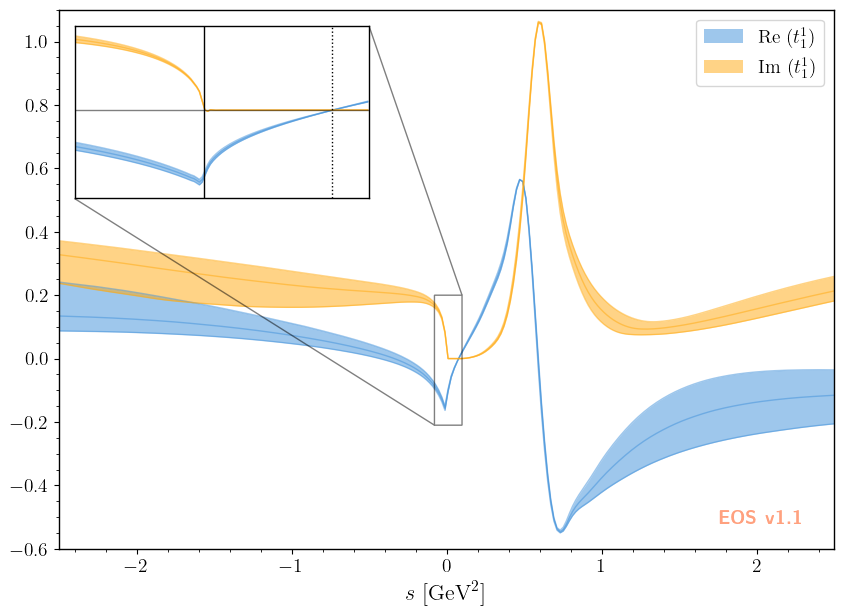

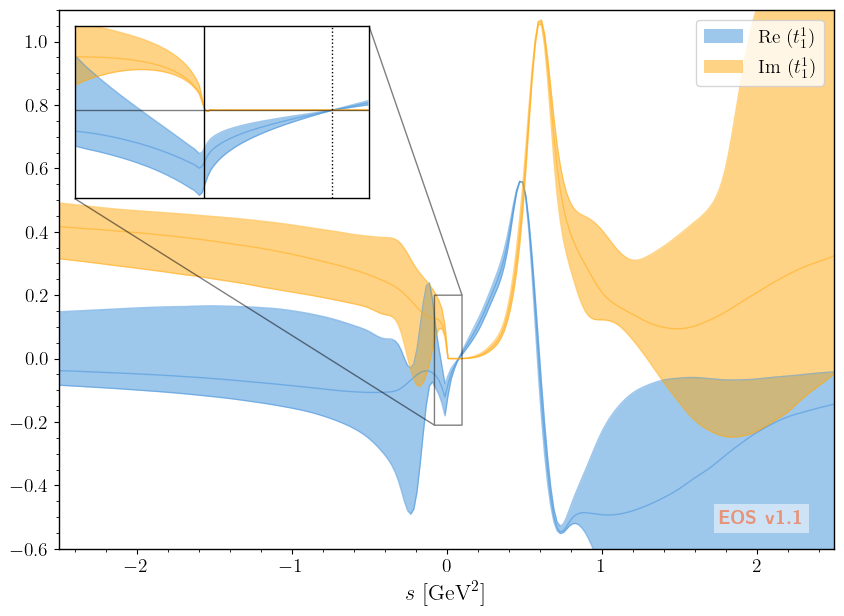

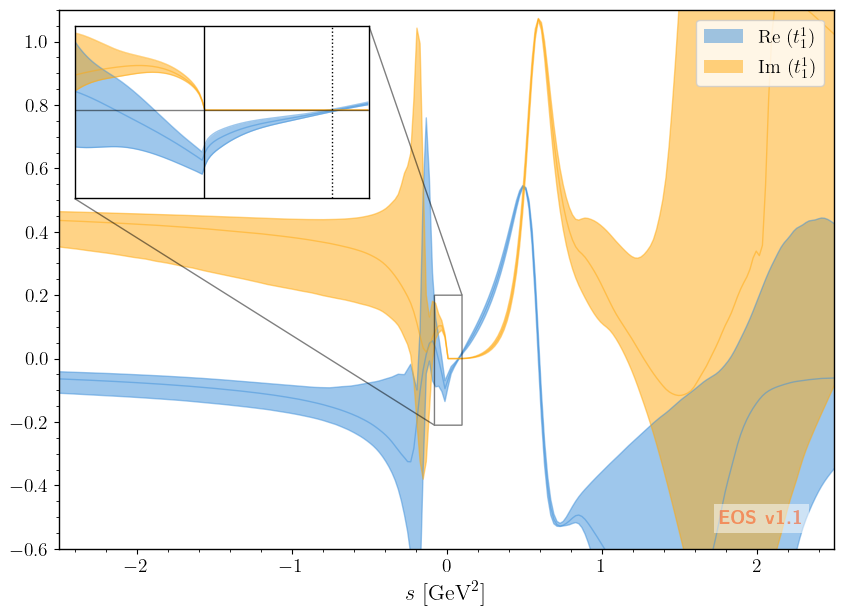

In [131]:
t11_figures = plot_t11_fits(fits, analysis_directory)

In [82]:
residue_datasets = [
    ("ALEPH 2013", "0->pipi::Abs{f_+}^2@ALEPH:2013A", colors[4]),
    ("Belle 2008", "0->pipi::Abs{f_+}^2@Belle:2008C", colors[0]),
    ("CLEO 2000",  "0->pipi::Abs{f_+}^2@CLEO:2000B", colors[1]),
    ("OPAL 1999",  "0->pipi::Abs{f_+}^2@OPAL:1999A", colors[5]),
]

def plot_residues_for_fit(label, folder, posterior):
    fit_directory = os.path.join(analysis_directory, folder)
    analysis_file = eos.AnalysisFile(
        os.path.join(fit_directory, "analysis.yaml")
    )
    analysis = analysis_file.analysis(posterior)

    mode = eos.data.Mode(
        os.path.join(fit_directory, "data", posterior, "mode-default")
    )

    output_names = {
        'FF-fp-I1-order6-without-Belle': 'reswo6',
        'FF-fp-I1-order8-without-Belle': 'reswo8',
        'FF-fp-I1-order8-Belle': 'resbelle8',
    }

    # Start with all parameters, including fixed ones, then insert
    # the saved best-fit values for the varied parameters.
    param_dict = {
        parameter.name(): parameter.evaluate()
        for parameter in analysis.parameters
    }
    for parameter, value in zip(analysis.varied_parameters, mode.mode):
        param_dict[parameter.name()] = float(value)

    fit_options = dict(analysis.init_args.get("global_options") or {})
    fit_options.setdefault("form-factors", "BHKMNR2026")

    items = [
        {
            "type": "constraint-residue",
            "label": dataset_label,
            "parameters": param_dict,
            "options": fit_options,
            "color": color,
            "variable": "q2",
            "observable": "0->pipi::Abs{f_+}^2(q2_min,q2_max)",
            "style": "delta",
            "constraints": constraint,
        }
        for dataset_label, constraint, color in residue_datasets
    ]

    figure_args = {
        "watermark": {"position": "lower right"},
        "plot": {
            "xaxis": {
                "label": r"$s$",
                "unit": r"$\mathrm{GeV}^2$",
                "range": [0.0, sIn],
            },
            "yaxis": {
                "label": (
                    r"$|F_\pi|^2_{\mathrm{data}}"
                    r" - |F_\pi|^2_{\mathrm{fit}}$"
                ),
                "range": [-4, 3],
                "scale": "linear",
            },
            "legend": {"position": "lower left"},
            "items": items,
        },
    }

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    figure.save(f'figures/{output_names[posterior]}.pdf')
    plt.show()
    return figure

Creating analysis with 5 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


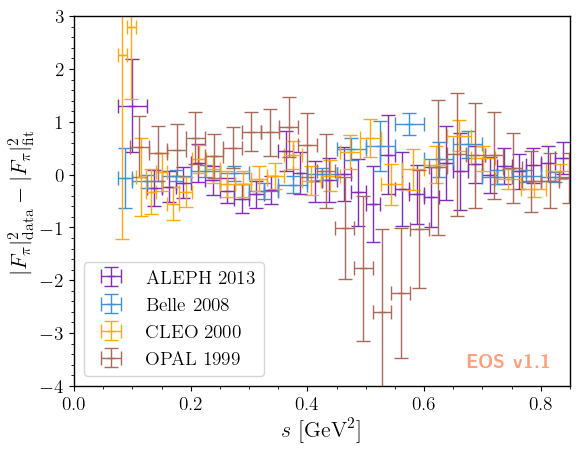

Creating analysis with 7 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


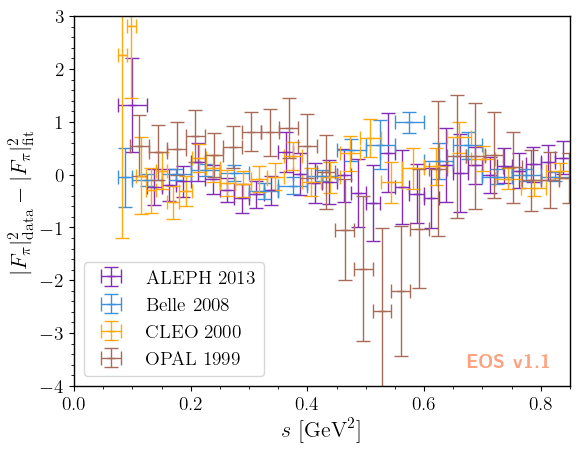

Creating analysis with 1 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


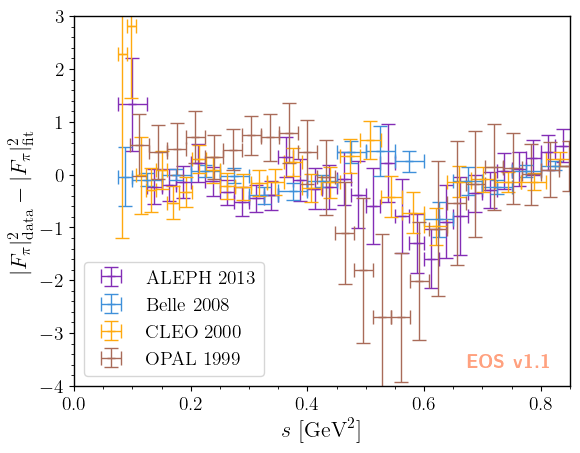

In [83]:
residue_figures = {}

for label, folder, posterior, _fit_color in fits:
    residue_figures[label] = plot_residues_for_fit(
        label, folder, posterior
    )

Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


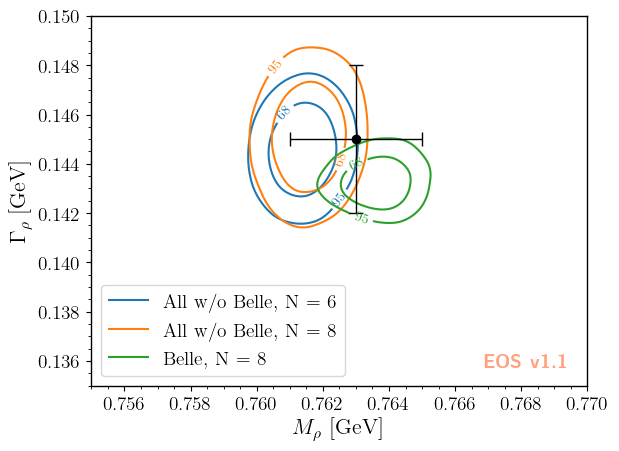

In [11]:
mass_gamma_items = [
    {
        "type": "kde2D",
        "label": label,
        "color": color,
        "levels": [68, 95],
        "contours": ["lines", "labels"],
        "bandwidth": 2.0,
        "datafile": os.path.join(
            analysis_directory, folder, "data", posterior, "samples"
        ),
        "variables": [
            "0->pipi::M_(+,1,0)@BHKMNR2026",
            "0->pipi::Gamma_(+,1,0)@BHKMNR2026",
        ],
    }
    for label, folder, posterior, color in fits
]

mass_gamma_items.append({
    "type": "errorbars",
    "positions": [[0.763, 0.145]],
    "xerrors": [0.002],
    "yerrors": [0.003],
    # "label": "PDG 2026",
    "marker": "o",
    "color": "black",
    "alpha": 1.0,
})

figure_args = {
    "watermark": {"position": "lower right"},
    "plot": {
        "xaxis": {
            "label": r"$M_\rho$",
            "unit": r"$\mathrm{GeV}$",
            "range": [0.755, 0.77],
        },
        "yaxis": {
            "label": r"$\Gamma_\rho$",
            "unit": r"$\mathrm{GeV}$",
            "range": [0.135, 0.15],
        },
        "legend": {"position": "lower left"},
        "items": mass_gamma_items,
    },
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
figure.save("figures/MvsGamma.pdf")

All w/o Belle, N = 6: <r_pi^2> = 0.4403 (+0.0043/-0.0044) fm^2
All w/o Belle, N = 8: <r_pi^2> = 0.4373 (+0.0056/-0.0058) fm^2
Belle, N = 8: <r_pi^2> = 0.4383 (+0.0052/-0.0051) fm^2


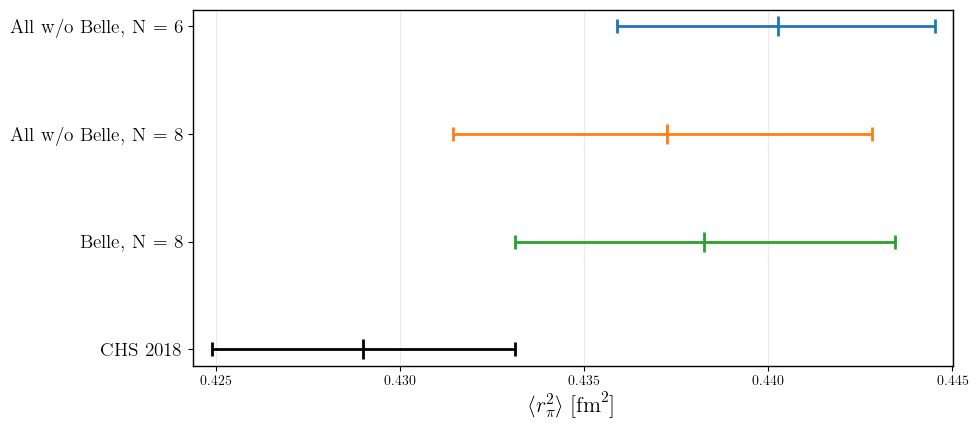

In [116]:
def plot_rpi_squared(fits, analysis_directory):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    plotted_values = []

    for y, (label, folder, posterior, color) in enumerate(fits):
        radius_path = os.path.join(
            analysis_directory,
            folder,
            "data",
            posterior,
            "charge-radius-squared.npz",
        )

        with np.load(radius_path) as saved:
            lower = float(saved["q16"])
            median = float(saved["q50"])
            upper = float(saved["q84"])

        minus_error = median - lower
        plus_error = upper - median
        plotted_values.extend([lower, upper])

        ax.errorbar(
            median,
            y,
            xerr=[[minus_error], [plus_error]],
            fmt="|",
            markersize=14,
            markeredgewidth=2,
            capsize=5,
            elinewidth=2,
            color=color,
        )

        print(
            f"{label}: <r_pi^2> = {median:.4f} "
            f"(+{plus_error:.4f}/-{minus_error:.4f}) fm^2"
        )

    # Colangelo reference.
    colangelo = 0.429
    colangelo_error = np.hypot(0.001, 0.004)
    plotted_values.extend([
        colangelo - colangelo_error,
        colangelo + colangelo_error,
    ])

    ax.errorbar(
        colangelo,
        len(fits),
        xerr=colangelo_error,
        fmt="|",
        markersize=14,
        markeredgewidth=2,
        capsize=5,
        elinewidth=2,
        color="black",
    )

    ax.set_yticks(
        range(len(fits) + 1),
        [label for label, _, _, _ in fits] + ["CHS 2018"],
    )
    ax.invert_yaxis()
    ax.set_xlabel(r"$\langle r_\pi^2\rangle\;[\mathrm{fm}^2]$")

    ax.set_xlim(
        min(plotted_values) - 0.0005,
        max(plotted_values) + 0.0005,
    )
    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=5, min_n_ticks=3, steps=[1, 2, 5, 10])
    )
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
    ax.tick_params(axis="x", labelrotation=0, labelsize=10)
    ax.grid(axis="x", alpha=0.25)

    fig.tight_layout()
    fig.savefig("figures/rpi2.pdf", bbox_inches="tight")
    plt.show()

    return fig


rpi2_figure = plot_rpi_squared(fits, analysis_directory)

In [134]:
def plot_timelike_phase_fits(fits, analysis_directory, output_name="arg_fpi_fits"):

    chs_path = os.path.join(analysis_directory, fits[0][1], "scripts", "d11-central.txt")
    q2_over_mpisquared, phase, err = np.loadtxt(chs_path, skiprows=1, unpack=True)
    q2 = q2_over_mpisquared * mpi**2

    items = []
    for label, folder, posterior, color in fits:
        prediction_path = os.path.join(
            analysis_directory,
            folder,
            "data",
            posterior,
            "pred-FF-arg-fp-I1-timelike",
        )
        if not os.path.exists(prediction_path):
            raise FileNotFoundError(
                f"No saved phase prediction for {label}: {prediction_path}"
            )

        items.append({
            "type": "uncertainty",
            "label": label,
            "color": color,
            "interpolation": "cubic",
            "resolution": 250,
            "variable": "q2",
            "datafile": prediction_path,
        })

    items.extend([
        {
            "type": "band",
            "color": "gray",
            "alpha": 0.25,
            "x": [sIn, 2.5],
            "y": [0.0, 3.8],
        },
        {
            "type": "expression",
            "expression": "np.pi",
            "range": [0.0, 2.5],
            "color": "black",
        },
    ])

    figure_args = {
        "watermark": {"position": "upper center"},
        "plot": {
            "xaxis": {
                "label": r"$s$",
                "unit": r"$\mathrm{GeV}^2$",
                "range": [0.0, 2.2],
            },
            "yaxis": {
                "label": r"$\arg F_\pi$",
                "range": [0.0, 3.8],
            },
            "legend": {"position": "lower right"},
            "items": items,
        },
    }

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    ax = figure._ax

    # Keep the three fit entries already made by EOS.
    legend = ax.get_legend()
    handles = list(legend.legend_handles)
    labels = [text.get_text() for text in legend.get_texts()]

    chs_band = ax.fill_between(
        q2,
        phase - err,
        phase + err,
        color='gray',
        alpha=0.5,
        label="CHS 2018",
    )
    threshold_line = ax.axvline(
        sPlus,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=r"$s_+$",
    )

    ax.legend(
        handles=handles + [chs_band],
        labels=labels + ["CHS 2018"],
        loc="lower right"
    )

    figure.save(f"figures/{output_name}.pdf")
    plt.show()
    return figure

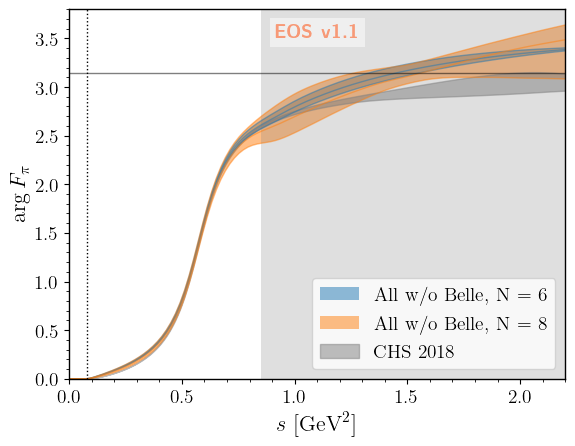

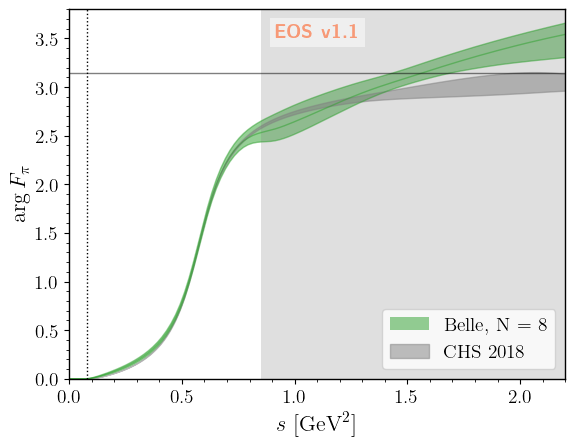

In [136]:
phase_without_belle = plot_timelike_phase_fits(
    fits[:2], analysis_directory, "arg_without_belle"
)

phase_belle = plot_timelike_phase_fits(
    fits[2:], analysis_directory, "arg_belle8"
)